### お弁当の需要予測
- 販売数のデータからお弁当の販売数`y`を予測する回帰モデルを作成する。
- データダウンロード先 -> [SIGNATEの練習問題データ](https://user.competition.signate.jp/ja/competition/detail/?competition=b2c7df3442d04e73bdbab95b1dd6f91d&task=4265b59bdd9d4b47af2771fe82dc9b52&tab=dataset)を使用


|属性          |説明                           |
|--------------|-------------------------------|
|datetime       |インデックスとして使用する日付  |
|y             |販売数                         |
|week          |曜日（月～金）                  |
|soldout       |完売フラグ（0:完売せず、1:完売）|
|name          |メインメニュー                  |
|kcal          |おかずのカロリー（kcal）        |
|remarks       |特記事項                        |
|event         |社内イベント                    |
|payday        |給料日フラグ（1:給料日）        |
|weather       |天気                           |
|precipitation |降水量                         |
|temperature   |気温                           |

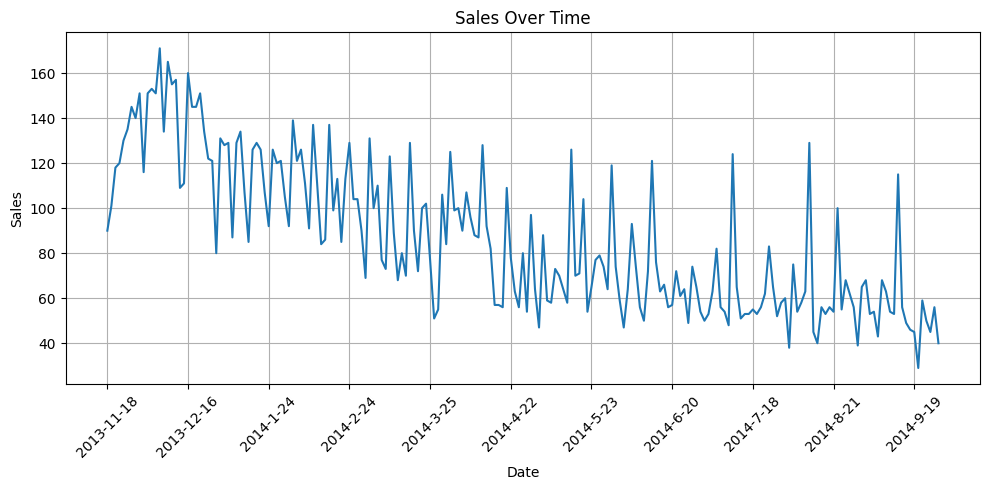

In [13]:
# 準備
# データの確認と売上グラフの描画

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data/secret/bento/train.csv')

df.head() # 最初の5行を表示


# 売上のグラフを描画
plt.figure(figsize=(10, 5))
plt.plot(df['datetime'], df['y'], marker='')
plt.xticks(df['datetime'][::len(df)//10]) # データポイントの10分の1ごとに表示
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()





### 欠損値の処理

In [ ]:
# 欠損値の確認
import pandas as pd

df = pd.read_csv('./data/secret/bento/train.csv')

print("データの基本情報:")
df.info() # データの基本情報を表示

print("\n欠損値の数:")
print(df.isnull().sum()) # 各列の欠損値の数を表示



データの基本情報:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       207 non-null    object 
 1   y              207 non-null    int64  
 2   week           207 non-null    object 
 3   soldout        207 non-null    int64  
 4   name           207 non-null    object 
 5   kcal           166 non-null    float64
 6   remarks        21 non-null     object 
 7   event          14 non-null     object 
 8   payday         10 non-null     float64
 9   weather        207 non-null    object 
 10  precipitation  207 non-null    object 
 11  temperature    207 non-null    float64
dtypes: float64(3), int64(2), object(7)
memory usage: 19.5+ KB

欠損値の数:
datetime           0
y                  0
week               0
soldout            0
name               0
kcal              41
remarks          186
event            193
payday           197
weather  

In [ ]:
# NaNを補完する
import pandas as pd

df = pd.read_csv('./data/secret/bento/train.csv')


print("kcalカラムの要約統計量:")
print(df['kcal'].describe()) # kcalカラムの要約統計量を

print('大きなばらつきがないため、平均値で補完します。')
df['kcal'] = df['kcal'].fillna(df['kcal'].mean()).astype(int) # 平均値で補完し、整数型に変換

df['payday'] = df['payday'].fillna(0) # paydayの欠損値を0で補完
df['event'] = df['event'].fillna('なし') # eventの欠損値を「なし」で補完
df['remarks'] = df['remarks'].fillna('特になし') # remarksの欠損値を「特になし」で補完


print("\n補完後の欠損値の数:")
print(df.isnull().sum()) # 補完後の欠損値の数を表示
df.head()

# csvファイルに保存
df.to_csv('./data/secret/bento/train_filled.csv', index=False)



kcalカラムの要約統計量:
count    166.000000
mean     404.409639
std       29.884641
min      315.000000
25%      386.000000
50%      408.500000
75%      426.000000
max      462.000000
Name: kcal, dtype: float64
大きなばらつきがないため、平均値で補完します。

補完後の欠損値の数:
datetime         0
y                0
week             0
soldout          0
name             0
kcal             0
remarks          0
event            0
payday           0
weather          0
precipitation    0
temperature      0
dtype: int64


### カテゴリカルデータの活用
データセットには、object型で示されるカテゴリカルデータが入っています。カテゴリカルデータは、そのままでは説明変数に用いることはできない。

数値データにカテゴリカルデータを変換する方法
- 手作業で数値に変換する
- One-Hot ベクトル（ダミー変数）に変換する
- Medean-Encodingする

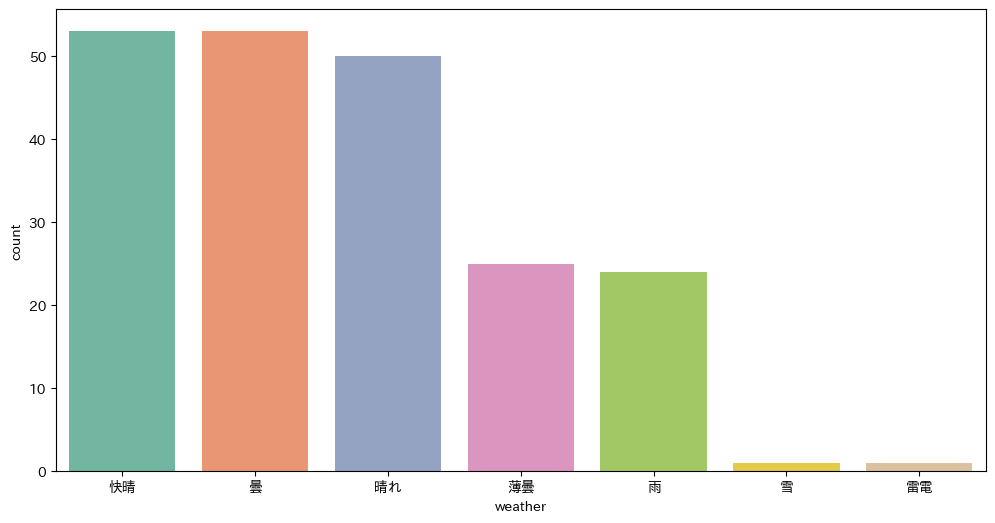

In [33]:
# weatherカラムの確認
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

df = pd.read_csv('./data/secret/bento/train_filled.csv')


plt.figure(figsize=(12, 6))
# カラーパレットを指定してカウントプロットを描画
sns.countplot(data=df, x='weather', hue='weather',palette='Set2', legend=False)
plt.show()

#### カテゴリカルデータの数値化

##### 順序数化
- 順序数に置き換えてしまう方法。
```python
df['weather'].map({
    '快晴': 0, '晴れ': 1, '薄曇': 2, '曇': 3, '雨': 4, '雷電': 5, '雪': 6
})
```
- 天候weatherの状態を正しく数値で表されたわけではないため、意味でもった数値データではない。
> カテゴリの間に「明らかな大小関係や順番（ランク）」が存在する場合にむいている。(弱・中・強、不満・普通。満足、など)

#### Medianエンコーディング
目的変数の中央値を採用する方法です。
```python
df.groupby('weather')['y'].median()
```
- 予測すべきyの値を中央値とはいえ説明変数に入れてしまっていることに注意
> メニュー名（name）」のように、種類が非常に多い場合に向いている
>   - メリット: 「このメニューが出たときは、過去の傾向としてこれくらい売れた（中央値）」という情報を1つの数値に凝縮できる。
>   - デメリット: 「ターゲットリーク」に注意が必要。学習データ内の正解をそのまま使って変換すると、未知のデータに対してモデルが全く通用しなくなる。


#### OneHotベクトル化
- ダミー変数化とも呼ぶ。定番手法。
```python
df_weather = pd.get_dummies(df['weather'], dummy_na=False, columns=['weather'])
df_weather.head()
```
> 天気（weather）」や「曜日（week）」など、種類が数件〜10数件程度の場合に向いている。
>   - メリット: 決定木モデル（LightGBMなど）が「晴れか、それ以外か」という分割を直感的に行える。
>   - デメリット: メニュー名のように種類が100を超えるほど増えると、疎（Sparse）な行列になり、学習効率が劇的に落ちる。

